# 02 - Treinamento da LSTM para previsão de taxas de gas

Pipeline com `data/EthereumGasFee.csv`:

1. **Dados** — CSV diário; coluna **Mean** (Gwei) como alvo univariado.
2. **Preparação** — Histórico **estritamente antes da janela de teste** para treino/validação (scaler só nesse período).
3. **Treino** — LSTM + early stopping (últimos 15% das sequências de treino).
4. **Avaliação** — **100 dias** em janela **2022-11-01 → 2023-02-08** (menor volatilidade). Previsão **um passo à frente** com janela deslizante.

**Por que o gráfico pode parecer “pior” que no notebook antigo?** Na versão antiga o `MinMaxScaler` costumava ser ajustado **em todo o CSV**, incluindo datas **futuras** em relação ao treino — isso **vaza informação** do intervalo de valores e deixa curvas real × predito artificialmente próximas. Agora o scaler usa **só o histórico antes do teste** (correto). Se no teste o Mean passa do máximo visto no treino, os inputs normalizados saem **fora de [0, 1]** e a rede reage mal; por isso aplicamos **clip** desses inputs na inferência (ver célula de previsão).


In [34]:
# Configuração e imports
# Use o kernel do .venv do projeto (Select Kernel -> Python Environments -> .venv).
# Se der ModuleNotFoundError, ative o venv, rode: pip install -r requirements.txt
# e selecione esse interpretador como kernel.
import sys
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib  # deve estar instalado no kernel (ex.: pip install -r requirements.txt no .venv)
import matplotlib.pyplot as plt
%matplotlib inline

# Raiz do projeto (assumindo que o notebook está em notebooks/)
ROOT = Path(".").resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Kernel Jupyter pode manter pacotes antigos em cache após editar src/
sys.modules.pop("src.features.build_features", None)
sys.modules.pop("src.models.lstm_model", None)
sys.modules.pop("src.models", None)

from datetime import datetime, timedelta

from src.data.fetch_blocks_goldrush import (
    _date_to_block_range,
    date_to_block_range_hours,
    fetch_blockchain_data,
)
from src.features.build_features import (
    SequenceConfig,
    clean_data,
    create_sequences,
    load_raw_data,
    minmax_transform_clip,
    scale_features,
)
from src.models.lstm_model import (
    build_lstm_model,
    forecast_sliding_onestep,
    save_model,
    train_lstm,
)

DATA_DIR = ROOT / "data"
MODEL_DIR = ROOT / "models"
MODEL_PATH = MODEL_DIR / "lstm_gas_price.h5"
SCALER_PATH = MODEL_DIR / "scaler.pkl"

# Janela de avaliação (100 dias, baixa volatilidade no CSV vs início de 2024)
PRED_START = pd.Timestamp("2022-11-01")
FORECAST_DAYS = 100
PRED_END_INCLUSIVE = PRED_START + pd.Timedelta(days=FORECAST_DAYS - 1)

INPUT_CSV = "EthereumGasFee.csv"  # arquivo em data/ (Date, Mean, Median, Percentile_75, Percentile_25). None = gerar via API.

if INPUT_CSV:
    p = Path(INPUT_CSV)
    CSV_OUT = p.resolve() if p.is_absolute() else DATA_DIR / p.name
    print(f"Processando dataset existente: {CSV_OUT}")
else:
    CHAIN = "eth-mainnet"
    BLOCKS_PER_HOUR = {"eth-mainnet": 300, "matic-mainnet": 1800}
    N_BLOCOS_1H = int(BLOCKS_PER_HOUR.get(CHAIN, 300))
    MODO_ULTIMA_HORA = True
    if MODO_ULTIMA_HORA:
        ONTEM = (datetime.utcnow() - timedelta(days=1)).strftime("%Y-%m-%d")
        START_BLOCK, END_BLOCK = date_to_block_range_hours(ONTEM, 1.0, CHAIN)
        CSV_OUT = DATA_DIR / "gas_data_1hora.csv"
        print(f"Modo: 1 hora em {ONTEM} (~{N_BLOCOS_1H} blocos) — {START_BLOCK} a {END_BLOCK}")
    else:
        DIAS = 5
        DATA_FIM = datetime.utcnow()
        DATA_INICIO = DATA_FIM - timedelta(days=DIAS)
        START_DATE = DATA_INICIO.strftime("%Y-%m-%d")
        END_DATE = DATA_FIM.strftime("%Y-%m-%d")
        CSV_OUT = DATA_DIR / "gas_data_5dias.csv"
        print(f"Modo: {DIAS} dias — {START_DATE} a {END_DATE}")
print(f"CSV: {CSV_OUT}")


Processando dataset existente: /Users/levidlima/Development/GasFeesPrediction/data/EthereumGasFee.csv
CSV: /Users/levidlima/Development/GasFeesPrediction/data/EthereumGasFee.csv


In [35]:

DATA_DIR.mkdir(parents=True, exist_ok=True)
if INPUT_CSV:
    df_raw = load_raw_data(CSV_OUT)
    print(f"Dataset carregado: {CSV_OUT} ({len(df_raw)} linhas)")
else:
    if MODO_ULTIMA_HORA:
        start_block, end_block = START_BLOCK, END_BLOCK
    else:
        start_block, end_block = _date_to_block_range(START_DATE, END_DATE, CHAIN)
    print(f"Blocos: {start_block} a {end_block}")
    df_raw = fetch_blockchain_data(
        start_block,
        end_block,
        chain_name=CHAIN,
        include_tx_count=False,
    )
    df_raw.to_csv(CSV_OUT, index=False)
    print(f"Dataset salvo: {CSV_OUT} ({len(df_raw)} linhas)")
df_raw.head()

Dataset carregado: /Users/levidlima/Development/GasFeesPrediction/data/EthereumGasFee.csv (1418 linhas)


,Date,Mean,Median,Percentile_75,Percentile_25
0,2020-06-15,28.250000,26.5,32.75,21.625
1,2020-06-16,26.741667,24.0,31.25,20.100
2,2020-06-17,29.745833,30.0,34.00,23.750
3,2020-06-18,25.789583,25.0,30.00,22.000
4,2020-06-19,27.304255,29.0,31.00,21.000


In [36]:
# 2. Carregar, limpar; treino com datas < PRED_START (Mean univariada)
df = load_raw_data(CSV_OUT)
df = clean_data(df)
time_col = (
    "Date"
    if "Date" in df.columns
    else ("signed_at" if "signed_at" in df.columns else "date")
)
if INPUT_CSV:
    feature_columns = ["Mean"]
    target_column = "Mean"
else:
    feature_columns = []
    target_column = "gas_used"
    for col in [
        "gas_used",
        "gas_limit",
        "base_fee",
        "tx_count",
        "Mean",
        "Median",
        "Percentile_75",
        "Percentile_25",
    ]:
        if col in df.columns and bool(df[col].notna().any()):
            feature_columns.append(col)
    if not feature_columns:
        for col in ["avgGasPrice_Gwei", "gasLimit", "gasUsed"]:
            if col in df.columns:
                feature_columns.append(col)
        target_column = (
            "avgGasPrice_Gwei" if "avgGasPrice_Gwei" in df.columns else feature_columns[0]
        )
    if "Mean" in df.columns and target_column == "gas_used":
        target_column = "Mean"
    if target_column not in df.columns or not bool(df[target_column].notna().any()):
        target_column = feature_columns[0]

df_pre = df.loc[df[time_col] < PRED_START].copy()
if len(df_pre) < 200:
    raise ValueError(f"Poucos dados antes de {PRED_START.date()}: {len(df_pre)} linhas")

df_pre_scaled, scaler = scale_features(df_pre, feature_columns=feature_columns)
config = SequenceConfig(target_column=target_column, window_size=30, forecast_horizon=1)
min_len = config.window_size + config.forecast_horizon
if len(df_pre_scaled) < min_len:
    new_window = max(5, len(df_pre_scaled) - config.forecast_horizon - 2)
    new_window = min(new_window, len(df_pre_scaled) - config.forecast_horizon)
    config = SequenceConfig(
        target_column=target_column, window_size=new_window, forecast_horizon=1
    )
    print(f"Ajuste: window_size={config.window_size} (antes do teste, {len(df_pre_scaled)} linhas)")

X, y = create_sequences(df_pre_scaled, feature_columns=feature_columns, config=config)
n_seq = len(X)
val_size = max(1, int(0.15 * n_seq))
X_train, y_train = X[:-val_size], y[:-val_size]
X_val, y_val = X[-val_size:], y[-val_size:]
print(
    f"Antes da janela de teste: {len(df_pre)} dias | Sequências: treino={len(y_train)}, val={len(y_val)}"
)
print(
    f"Features: {feature_columns}, alvo: {target_column}, janela={config.window_size}"
)


Antes da janela de teste: 869 dias | Sequências: treino=714, val=125
Features: ['Mean'], alvo: Mean, janela=30


In [37]:
# 3. Construir e treinar a LSTM
model = build_lstm_model(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    learning_rate=3e-3,
)
history = train_lstm(
    model, X_train, y_train, X_val, y_val,
    batch_size=32,
    epochs=1000,
)
print("Última loss (val):", history.history["val_loss"][-1])

Epoch 1/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0127 - mae: 0.0809 - val_loss: 3.7369e-04 - val_mae: 0.0167 - learning_rate: 0.0030
Epoch 2/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0039 - mae: 0.0397 - val_loss: 0.0010 - val_mae: 0.0304 - learning_rate: 0.0030
Epoch 3/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0049 - mae: 0.0423 - val_loss: 7.4459e-04 - val_mae: 0.0250 - learning_rate: 0.0030
Epoch 4/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0056 - mae: 0.0425 - val_loss: 3.2951e-04 - val_mae: 0.0156 - learning_rate: 0.0030
Epoch 5/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0057 - mae: 0.0413 - val_loss: 3.2778e-04 - val_mae: 0.0154 - learning_rate: 0.0030
Epoch 6/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0037 - mae: 0.0362 - val_loss: 4.8167e-04 - val_mae: 0.0194 - learning_rate: 0.0030
Epoch 7/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0047 - mae: 0.0396 - val_loss: 3.0656e-04 - val_mae: 0.0146 - lear

In [38]:
# 4. Salvar modelo, scaler e metadados da janela de avaliação
MODEL_DIR.mkdir(parents=True, exist_ok=True)
save_model(model, MODEL_PATH)
joblib.dump(
    {
        "scaler": scaler,
        "feature_columns": feature_columns,
        "sequence_config": config,
        "time_column": time_col,
        "forecast": {
            "pred_start": str(PRED_START.date()),
            "pred_end_inclusive": str(PRED_END_INCLUSIVE.date()),
            "forecast_days": FORECAST_DAYS,
            "mode": "sliding_onestep",
        },
    },
    SCALER_PATH,
)
print(f"Modelo: {MODEL_PATH}")
print(f"Bundle (scaler + meta): {SCALER_PATH}")


Modelo: /Users/levidlima/Development/GasFeesPrediction/models/lstm_gas_price.h5
Bundle (scaler + meta): /Users/levidlima/Development/GasFeesPrediction/models/scaler.pkl


In [39]:
# 5. Previsão 1 passo à frente (janela deslizante)
# Para cada posição i: prevê o dia i com scaled_all[i - window : i] (só histórico real).
col_idx = feature_columns.index(target_column)

df_ord = df.sort_values(time_col, kind="mergesort").reset_index(drop=True)
ts = pd.to_datetime(df_ord[time_col], errors="coerce")
if ts.isna().any():
    raise ValueError("Existem datas inválidas na coluna temporal.")

hit = np.flatnonzero((ts >= PRED_START).to_numpy())
if hit.size == 0:
    raise ValueError(f"Nenhuma data >= {PRED_START.date()} no CSV.")
i0 = int(hit[0])

if i0 < config.window_size:
    raise ValueError(
        f"Índice inicial {i0} < janela {config.window_size}. "
        "Precisa de mais histórico antes do primeiro dia avaliado."
    )

scaled_all = minmax_transform_clip(
    scaler, df_ord[feature_columns].astype(float)
)
if scaled_all.shape[0] != len(df_ord):
    raise ValueError("len(scaled_all) deve coincidir com len(df_ord).")

tail_ts = ts.to_numpy()[i0:]
v_end = np.datetime64(pd.Timestamp(PRED_END_INCLUSIVE).to_datetime64())
n_in_period = int(np.searchsorted(tail_ts, v_end, side="right"))
n_eval = min(FORECAST_DAYS, n_in_period, len(df_ord) - i0)
if n_eval <= 0:
    raise ValueError(
        "n_eval <= 0: confira PRED_START, PRED_END_INCLUSIVE e o conteúdo do CSV."
    )

d0 = ts.iloc[i0]
if d0.normalize() != PRED_START.normalize():
    print(
        "Aviso: sem linha exata em",
        PRED_START.date(),
        "— primeira data avaliada:",
        d0.date(),
    )

y_pred_scaled = forecast_sliding_onestep(
    model,
    scaled_all,
    start_index=i0,
    n_steps=n_eval,
    window_size=config.window_size,
)

n_pred = len(y_pred_scaled)
dummy = np.zeros((n_pred, len(feature_columns)))
dummy[:, col_idx] = y_pred_scaled
y_pred_2024 = scaler.inverse_transform(dummy)[:, col_idx]

eval_slice = df_ord.iloc[i0 : i0 + n_pred]
y_true_2024 = eval_slice[target_column].to_numpy(dtype=np.float64)
dates_2024 = eval_slice[time_col].to_numpy()

if n_pred != len(y_true_2024):
    raise ValueError(
        f"Desalinhamento: len(pred)={n_pred}, len(real)={len(y_true_2024)}."
    )

if n_pred < FORECAST_DAYS:
    print(
        f"Aviso: só {n_pred} dia(s) no intervalo do CSV (pedido {FORECAST_DAYS})."
    )


In [40]:
# Métricas na janela de avaliação (escala original)
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_2024 = mean_absolute_error(y_true_2024, y_pred_2024)
rmse_2024 = np.sqrt(mean_squared_error(y_true_2024, y_pred_2024))
print(f"MAE (100 dias, janela estável): {mae_2024:.4f}")
print(f"RMSE (100 dias, janela estável): {rmse_2024:.4f}")


MAE (100 dias, janela estável): 2.8027
RMSE (100 dias, janela estável): 4.6945


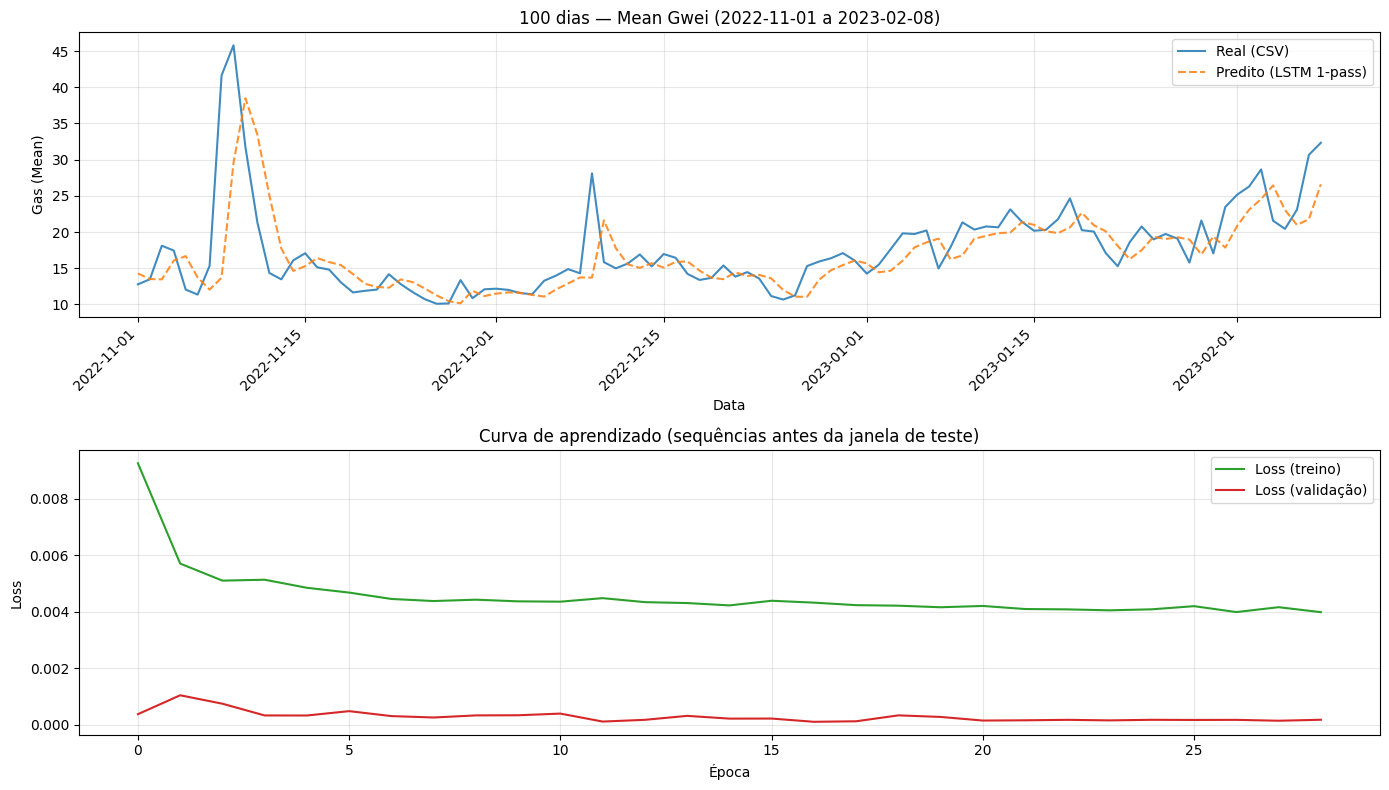

In [41]:
# 6. Gráficos: janela de avaliação vs curva de loss
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax1 = axes[0]
ax1.plot(dates_2024, y_true_2024, label="Real (CSV)", color="tab:blue", alpha=0.85)
ax1.plot(
    dates_2024,
    y_pred_2024,
    label="Predito (LSTM 1-pass)",
    color="tab:orange",
    alpha=0.85,
    linestyle="--",
)
ax1.set_xlabel("Data")
ax1.set_ylabel(f"Gas ({target_column})")
ax1.set_title(
    f"100 dias — Mean Gwei ({PRED_START.date()} a {PRED_END_INCLUSIVE.date()})"
)
ax1.legend(loc="upper right")
ax1.grid(True, alpha=0.3)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")

ax2 = axes[1]
ax2.plot(history.history["loss"], label="Loss (treino)", color="tab:green")
ax2.plot(history.history["val_loss"], label="Loss (validação)", color="tab:red")
ax2.set_xlabel("Época")
ax2.set_ylabel("Loss")
ax2.set_title("Curva de aprendizado (sequências antes da janela de teste)")
ax2.legend(loc="upper right")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Modelo e métricas prontos para o notebook 03_demonstracao_predicao.ipynb
